In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [24]:
def extract_state_runs(states, min_length=10):
    state_snippets = []
    buffer = 10  # number of frames removed at beg/end of session 
    i_beg = buffer
    curr_state = states[i_beg]
    curr_len = 1
    temp = []
    for i in range(i_beg + 1, len(states) - buffer):
        next_state = states[i]
        if next_state == curr_state+1:
            temp.append(curr_state)    
        else:
            if len(temp) >= min_length:
                state_snippets.append(temp)
            temp = [curr_state]
        curr_state = next_state
    
    return state_snippets

In [2]:
def get_results(base, mod, v):
    preds = []
    for vid in test_vids:
        #print(base.format(mod, v, vid))
        p = np.load(base.format(mod, v, vid))
        p = p.argmax(axis=1)
        preds += list(p)
    preds = np.array(preds)
    return preds

def get_f1_dict(suffix='states'):
    mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/{}_' + suffix + '.npy'
    f1_meta = {}
    #mods = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']

    for mod in model_list:
        f1_meta[mod] = []
        for v in range(5):
            preds = get_results(mod_base, mod,v)
            f1 = f1_score(states[states>0], preds[states>0], average=None)
            f1_meta[mod].append([np.mean(f1)] + list(f1))
            
    # aggregate results
    f1_plot = {}
    for mod in model_list:
        mean_list = []
        sd_list = []
        for p in range(len(labels)):
            mean = np.mean([a[p] for a in f1_meta[mod]])
            sd = np.std([a[p] for a in f1_meta[mod]])/5
            mean_list.append(mean)
            sd_list.append(sd)
        f1_plot[mod] = (mean_list, sd_list)
        
    return f1_plot

    
def plot_f1(f1_plot, it='regular markers'):
    # Numbers of pairs of bars you want
    N = len(label_names)
    # Position of bars on x-axis
    ind = np.arange(N)

    colors = ['black', 'grey', 'lightgrey', 'slategrey', 'peru', 'brown']
    # Figure size
    plt.figure(figsize=(8,5))

    # Width of a bar 
    width = 0.15     
    i=0
    for mod, (mean, sd) in f1_plot.items():
        if i==0:
            print(mean)
        # Plotting
        label = mod
        if mod == 'nope':
            label='none'
        plt.bar(ind + width*i, mean, width, label=label, color=colors[i],yerr=sd)
        plt.xlabel('classes')
        plt.ylabel('F1 score')
        plt.title('F1 scores with different transforms ({})'.format(it))
        plt.xticks(ind + width, label_names)
        i+=1

    # Finding the best position for legends and putting it
    plt.legend(loc='best')
    plt.show()
    
def make_df(suffix='states', labeled_only=True):
    if labeled_only:
        gt = states[states > 0]
    else:
        gt = states
    
    df_std = []
    ind_count = 0
    
    for mod in model_list:
        all_res = []
        print(mod)
        
        # Collect results for each fold
        for v in range(5):
            res = get_results(mod_base, mod, v)
            if labeled_only:
                res = res[states > 0]
            all_res.append(res)
        
        # Convert all_res to a numpy array for vectorized operations
        all_res = np.array(all_res)
        
        # Calculate predictions and statistics
        modes = stats.mode(all_res, axis=0).mode[0]
        stds = all_res.std(axis=0)
        corrects = (gt == modes).astype(int)
        
        # Construct the DataFrame in one go
        rows = {
            'model': [mod] * len(gt),
            'gt_action': gt,
            'prediction': modes,
            'correct': corrects,
            'std': stds,
            'dtype': [suffix] * len(gt)
        }
        df_std.append(pd.DataFrame(rows, index=np.arange(ind_count, ind_count + len(gt))))
        ind_count += len(gt)
    
    df_std = pd.concat(df_std, ignore_index=True)
    return df_std    


def make_graph_df(df_std):
    # make df to graph
    std_vals = np.arange(0, 3, 0.05)
    n_points_dict = {m: np.nan * np.zeros_like(std_vals) for m in model_list}
    df_line2 = []
    for s, std in enumerate(std_vals):
        #print(std)
        df_tmp_ = df_std[df_std['std'] >= std]
        for model_name in model_list:
            d = df_tmp_[df_tmp_.model == model_name]
            n_points = np.sum(~d['correct'].isna())
            n_points_dict[model_name][s] = n_points
            index = []
            rng = 0
            for row, k in zip(d.index, range(len(d))):
                index.append(f'{row}' + f'_{model_name}_{s}_{k}_{rng}')
            accuarcy = d['correct'].to_numpy()
            df_line2.append(pd.DataFrame({
                'ens-std': std,
                'model': model_name,
                'accuracy': accuarcy,
                'n_points': n_points,
            }, index=index))
    df_line2 = pd.concat(df_line2)
    return df_line2

def make_graph(df_line2):
    # graph df
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))  # Increase the figure size
    g = sns.lineplot(
        x='ens-std',
        y='accuracy',
        hue='model',
        hue_order=model_list,
        #palette=palette,
        data=df_line2,
        ax=ax,
        errorbar='se'
    )
    labels_fontsize=12
    handles, labels = ax.get_legend_handles_labels()
    legend_labels = {
        'nope': 'no transforms',
        'all': 'all transforms',
    }
    ax.legend(
        handles=handles,
        labels=[legend_labels.get(label, label) for label in labels],
        loc='upper left',
        bbox_to_anchor=(1, 1),
        fontsize=labels_fontsize,
        title='model',
        title_fontsize=labels_fontsize
    )

    ax.set_title(suffix)
    return ax

In [3]:
# load gt labels
test_vids = [
    'churchlandlab_CSHL045_2020-02-27-001',
    'cortexlab_KS020_2020-02-06-001',
    'hoferlab_SWC_043_2020-09-15-001',
    'mrsicflogellab_SWC_052_2020-10-22-001',
    'wittenlab_ibl_witten_27_2021-01-21-001',
]
label_names = ['avg', 'still', 'move', 'wheel_turn', 'groom']

base = '/home/bsb2144/daart_utils/data/ibl/labels-hand/{}_labels.csv'
labels = {}
states = []
for vid in test_vids:
    labs = pd.read_csv(base.format(vid),index_col=0).to_numpy()
    labs = labs.argmax(axis=1)
    states += list(labs)
    labels[vid] = labs
states = np.array(states)

In [4]:
# make df with cols
# model_name | gt_action | prediction | correct (0/1) | SD | dtype
#suffix: states | markers-new | markers-smooth 
model_list = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']
suffix='states'
mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/{}_' + suffix + '.npy'

In [5]:
df_std = make_df(suffix=suffix,labeled_only=True)
df_line2 = make_graph_df(df_std)

nope
all
rotate
shift
gauss
shot


<AxesSubplot:title={'center':'states'}, xlabel='ens-std', ylabel='accuracy'>

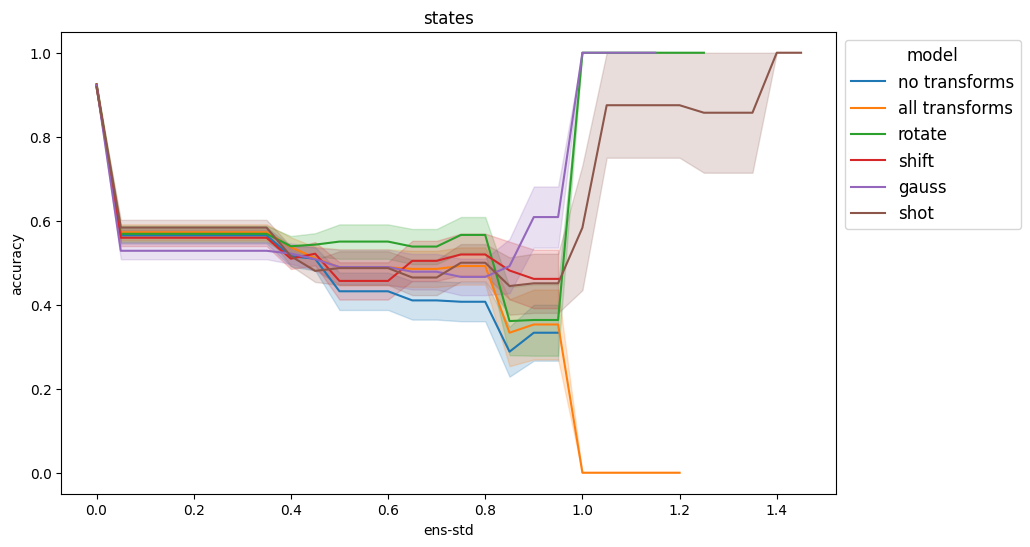

In [6]:
make_graph(df_line2)

In [7]:
# graph high std vs traces
#model_list = ['nope']
model_list = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']
suffix='states'
mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/{}_' + suffix + '.npy'
df_std2 = make_df(suffix,labeled_only=False)
print(df_std2.shape)


nope
all
rotate
shift
gauss
shot
(3000000, 6)


In [33]:
# each vid has 100,000 frames
# 5 test videos
n_vids=5
n_frames=100000
df_reg = df_std2[df_std2['model']=='nope']
df_pstd = df_reg#[df_reg['std']!=0]
df_pstd['vid_id'] = (df_pstd.index // n_frames)
df_pstd['frame_id'] = (df_pstd.index) - (df_pstd['vid_id'] * n_frames)
df_pstd['vid_name'] = [test_vids[i] for i in df_pstd['vid_id']]
df_pstd=df_pstd.reset_index()
print(df_pstd.shape)
#display(df_pstd)
#df_pstd.to_csv('results/std_df.csv')

(500000, 10)


/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [35]:
df_sd = df_reg[df_reg['std']!=0]
df_sd['vid_id'] = (df_sd.index // n_frames)
df_sd['frame_id'] = (df_sd.index) - (df_sd['vid_id'] * n_frames)
df_sd['vid_name'] = [test_vids[i] for i in df_sd['vid_id']]
df_sd=df_sd.reset_index()
print(df_sd.shape)
display(df_sd)
#df_pstd.to_csv('results/std_df.csv')

(62376, 10)


/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

,index,model,gt_action,prediction,correct,std,dtype,vid_id,frame_id,vid_name
0,429,nope,0,1,0,0.400000,states,0,429,churchlandlab_CSHL045_2020-02-27-001
1,430,nope,0,1,0,0.400000,states,0,430,churchlandlab_CSHL045_2020-02-27-001
2,431,nope,0,1,0,0.400000,states,0,431,churchlandlab_CSHL045_2020-02-27-001
3,432,nope,0,1,0,0.489898,states,0,432,churchlandlab_CSHL045_2020-02-27-001
4,433,nope,0,1,0,0.489898,states,0,433,churchlandlab_CSHL045_2020-02-27-001
...,...,...,...,...,...,...,...,...,...,...
62371,499926,nope,0,1,0,0.800000,states,4,99926,wittenlab_ibl_witten_27_2021-01-21-001
62372,499973,nope,0,3,0,0.800000,states,4,99973,wittenlab_ibl_witten_27_2021-01-21-001
62373,499974,nope,0,3,0,0.979796,states,4,99974,wittenlab_ibl_witten_27_2021-01-21-001
62374,499993,nope,0,1,0,0.489898,states,4,99993,wittenlab_ibl_witten_27_2021-01-21-001


In [42]:
runs = extract_state_runs(list(df_sd['frame_id']), min_length=20)
print(len(runs))
#[print(len(r)) for r in runs]

371


In [47]:
# graph keypoints vs ens-sd for ens-sd > 0
m_base = "/home/bsb2144/daart_utils/data/ibl/markers/{}_labeled.npy"
for vid in test_vids:
    markers = np.load(m_base.format(vid))
    sds = df_pstd[df_pstd['vid_name']==vid]['std']
    runs = extract_state_runs(list(df_sd[df_sd['vid_name']==vid]['frame_id']), min_length=30)
    print(len(runs))

12
47
12
9
14


In [73]:
# for mod in model_list:
#     print(mod)
#     zs = len(df_std[df_std['model']==mod][df_std['std']==0])
#     den = len(df_std[df_std['model']==mod])
#     print(zs/den)